In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import seaborn as sns
from matplotlib import pyplot as plt

sns.set_style('darkgrid')

params = {'legend.fontsize': 'medium',
          'figure.figsize': (10, 8),
          'figure.dpi': 100,
         'axes.labelsize': 'medium',
         'axes.titlesize':'medium',
         'xtick.labelsize':'medium',
         'ytick.labelsize':'medium'}
plt.rcParams.update(params)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


/kaggle/input/movielens-9000-movies-dataset/ml-latest-small/movies.csv
/kaggle/input/movielens-9000-movies-dataset/ml-latest-small/ratings.csv
/kaggle/input/movielens-9000-movies-dataset/ml-latest-small/README.txt
/kaggle/input/movielens-9000-movies-dataset/ml-latest-small/tags.csv
/kaggle/input/movielens-9000-movies-dataset/ml-latest-small/links.csv


# EDA - MovieLens 9000 movies datasets

This dataset (ml-latest-small) describes 5-star rating and free-text tagging activity from MovieLens, a movie recommendation service. It contains 100836 ratings and 3683 tag applications across 9742 movies. These data were created by 610 users between March 29, 1996 and September 24, 2018. This dataset was generated on September 26, 2018.

Users were selected at random for inclusion. All selected users had rated at least 20 movies. No demographic information is included. Each user is represented by an id, and no other information is provided.

In [2]:
rating_df = pd.read_csv('/kaggle/input/movielens-9000-movies-dataset/ml-latest-small/ratings.csv')
movie_df = pd.read_csv('/kaggle/input/movielens-9000-movies-dataset/ml-latest-small/movies.csv')

In [3]:
rating_df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [4]:
movie_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
rating_df = pd.merge(rating_df, movie_df, on='movieId')

In [6]:
rating_df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,5,1,4.0,847434962,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
2,7,1,4.5,1106635946,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
3,15,1,2.5,1510577970,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
4,17,1,4.5,1305696483,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy


## Total number of Ratings 

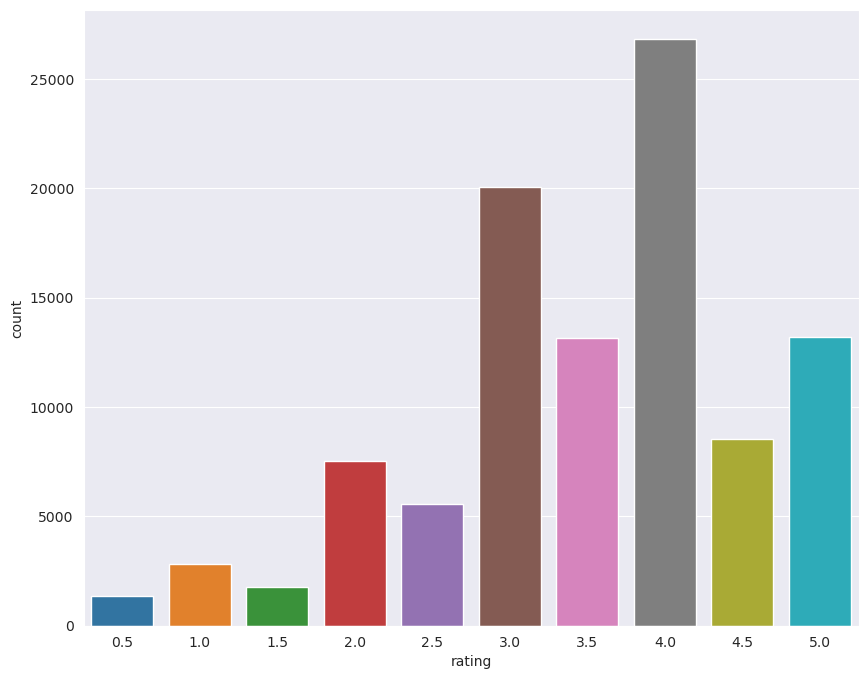

In [7]:
sns.countplot(x='rating', data=rating_df)
plt.show()

## Top 20 movies with highest Ratings

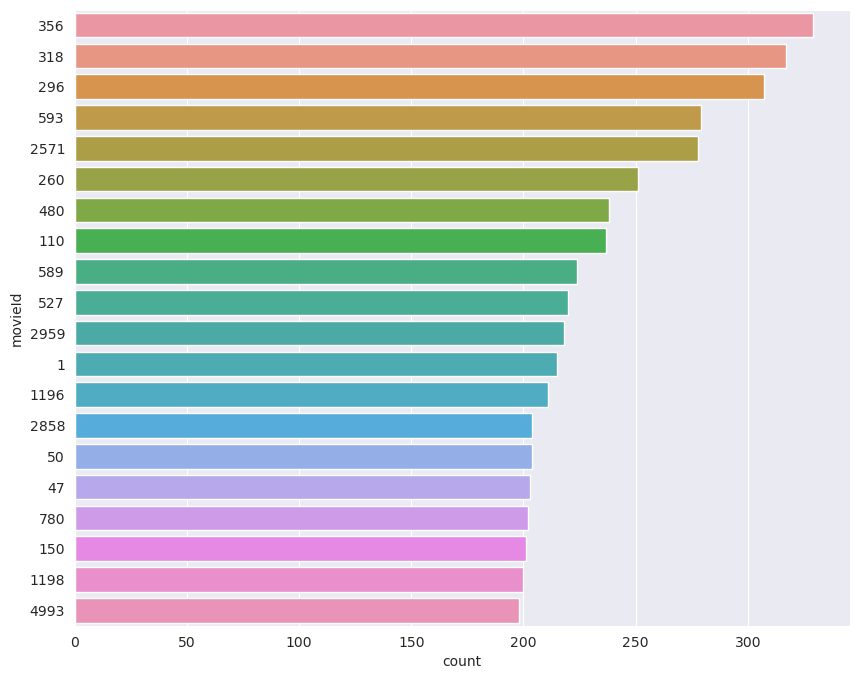

In [8]:
sns.countplot(y='movieId', data=rating_df, order=rating_df.movieId.value_counts()[:20].index)
plt.show()

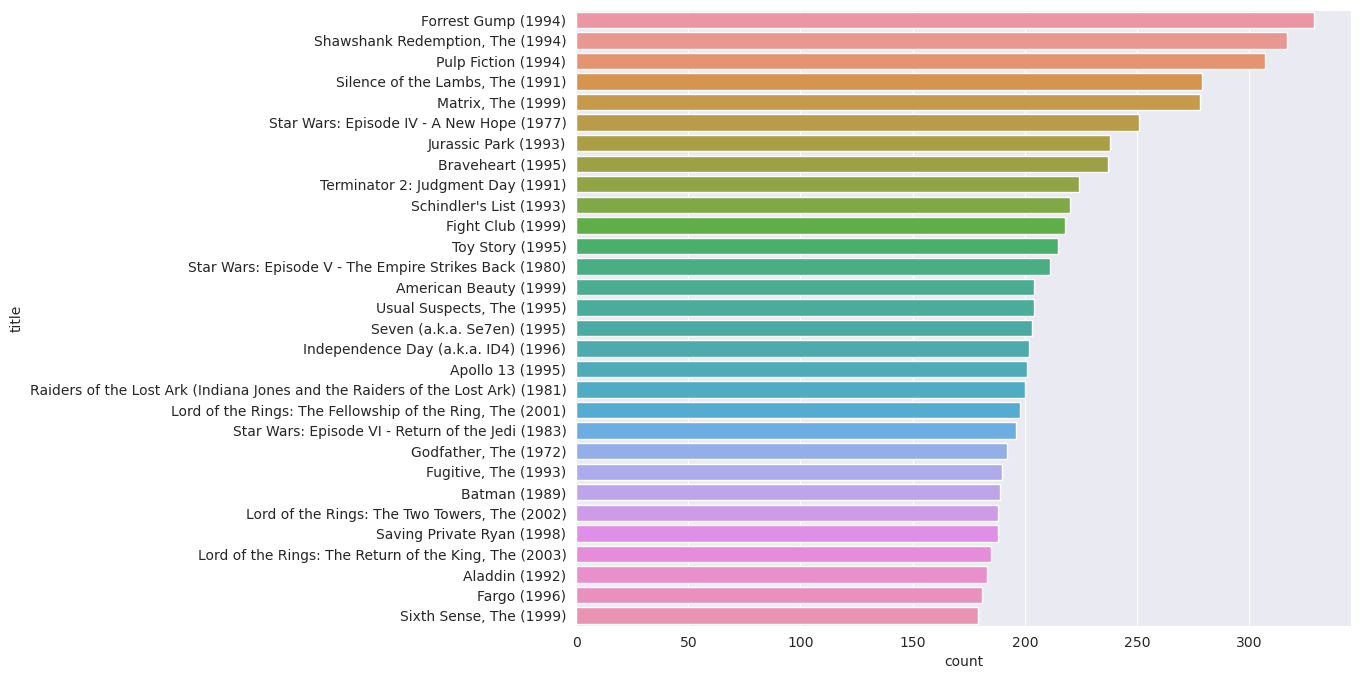

In [9]:
sns.countplot(y='title', data=rating_df, order=rating_df.title.value_counts()[:30].index)
plt.show()

## Total number of ratings count by top 20 user

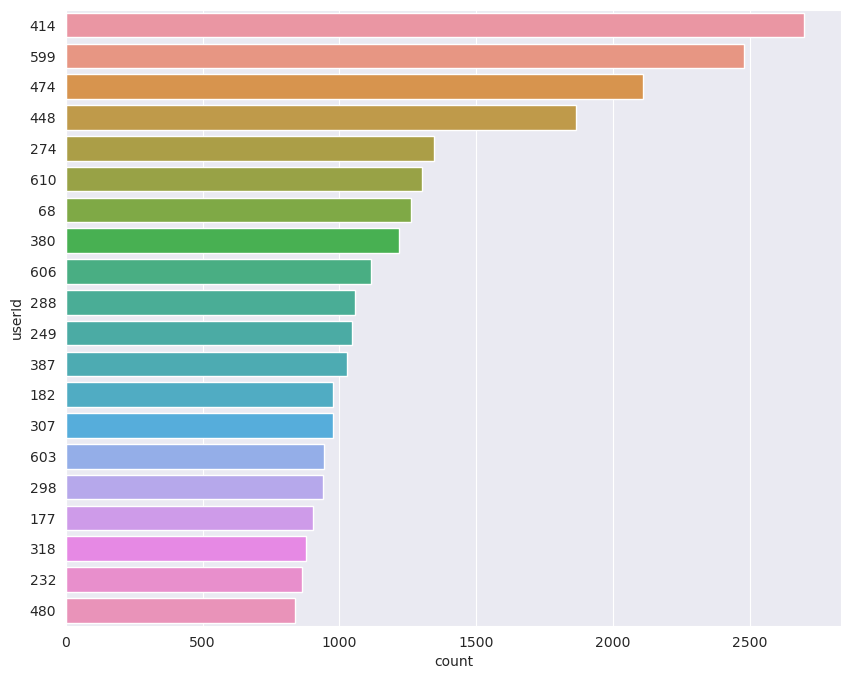

In [10]:
sns.countplot(y='userId', data=rating_df, order=rating_df.userId.value_counts()[:20].index)
plt.show()

# Each user ratings min / max 

In [11]:
rating_df.userId.value_counts()[:5]

414    2698
599    2478
474    2108
448    1864
274    1346
Name: userId, dtype: int64

In [12]:
rating_df.userId.value_counts(ascending=True)[:5]

406    20
189    20
595    20
442    20
320    20
Name: userId, dtype: int64

# Each movie ratings min / max 

In [13]:
rating_df.movieId.value_counts()[:5]

356     329
318     317
296     307
593     279
2571    278
Name: movieId, dtype: int64

In [14]:
rating_df.movieId.value_counts(ascending=True)[:15]

163981    1
142602    1
142961    1
5706      1
5468      1
151759    1
4942      1
160569    1
164280    1
4434      1
3648      1
171701    1
171759    1
172013    1
172461    1
Name: movieId, dtype: int64